In [1]:
# Cargamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
# Cargamos el dataset
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/ML/housing.csv")  # Modificar según ruta donde se almacene

print(df.head()) # Los datos cargaron correctamente


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Se observa que total_bedrooms tiene algunos datos faltantes, que ocean_proximity es categórica y que hay un total de 20640 muestras.
Como el modelo lo entrenaremos con las coordenadas, no haremos ningun tratamiento con las otras variables.

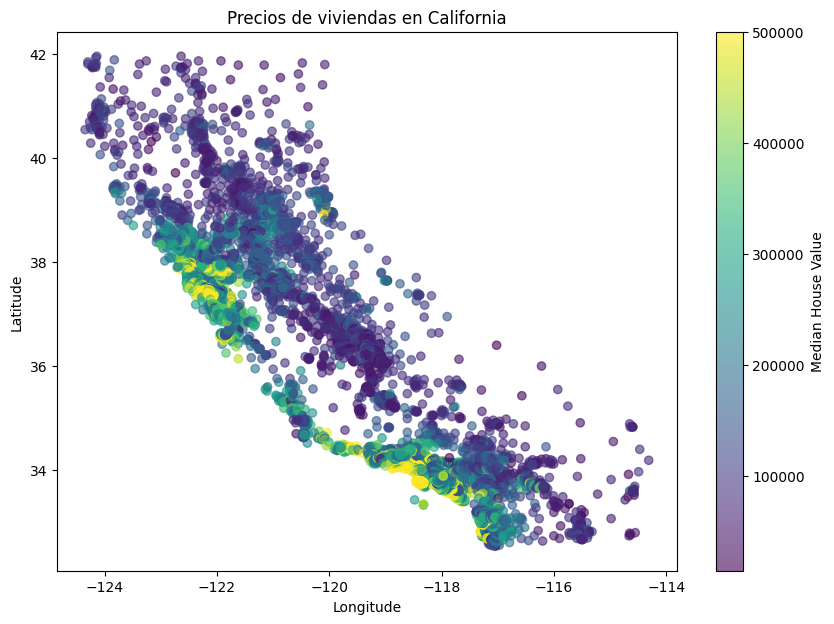

In [5]:
# Realizamos el gráfico de dispersión
plt.figure(figsize=(10, 7))
plt.scatter(
    df['longitude'], df['latitude'],
    c=df['median_house_value'],
    cmap='viridis', alpha=0.6)
plt.colorbar(label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Precios de viviendas en California')
plt.show()

Observamos que en la parte costera los precios son más elevados y en el centro-norte también hay precios más elevados.

In [6]:
# Normalizamos las variables de interes
X = df[['latitude','longitude']]

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [7]:
# Entrenamos el modelo con 3 clusters
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

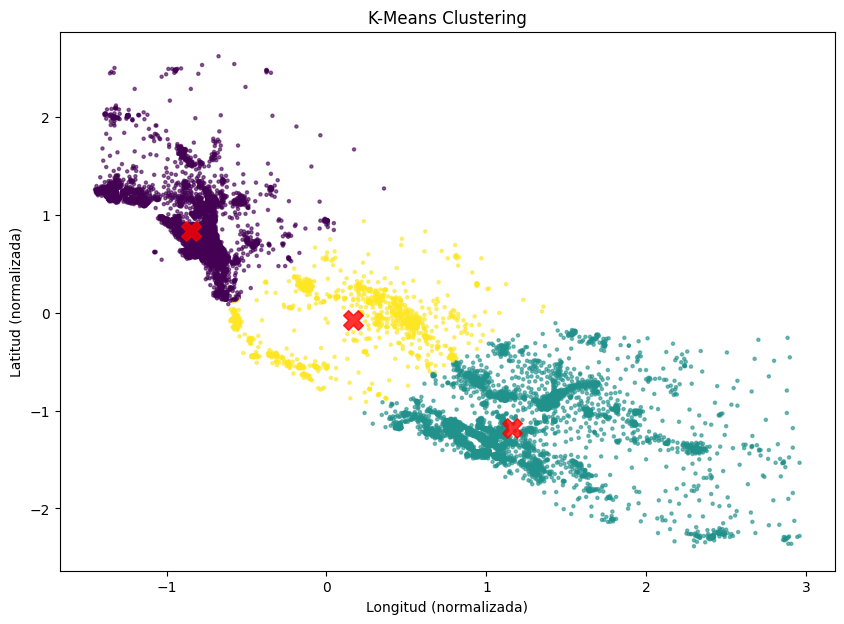

In [8]:
# Visualizamos los grupos
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=5, cmap='viridis', alpha=0.6)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X', label='Centroides')

plt.title('K-Means Clustering')
plt.xlabel('Longitud (normalizada)')
plt.ylabel('Latitud (normalizada)')
plt.show()

Hay tres divisiones de clústeres, una en la parte norte, en el centro y en el sur.

In [9]:
score = silhouette_score(X, y_kmeans)
print(f"Puntuación de silueta (k=3): {score:.3f}")

Puntuación de silueta (k=3): 0.647


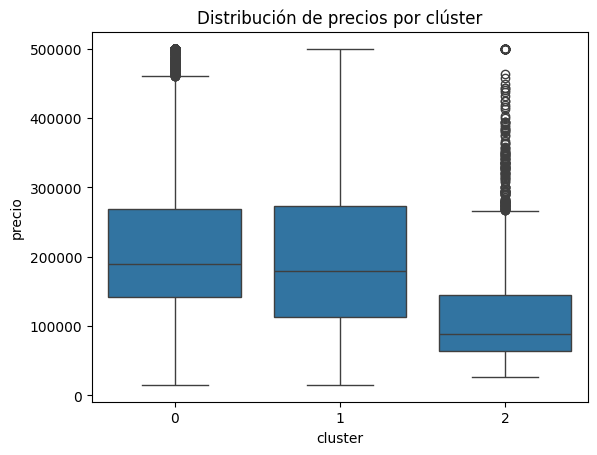

In [10]:
Y = df["median_house_value"]
df_result = pd.DataFrame({'cluster': y_kmeans, 'precio': Y})
sns.boxplot(x='cluster', y='precio', data=df_result)
plt.title('Distribución de precios por clúster')
plt.show()

La puntuación de la silueta es buena, pero los clusteres no agrupan demasiado bien el precio de la vivienda, especialmente la parte del centro y la del sur.

In [11]:
# Entrenamos el modelo con diferentes clusters
k_m = [2,3,4,5,6,7,8]
resultados = []
for k in k_m:
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X)
  y_kmeans = kmeans.predict(X)
  resultados.append(kmeans.inertia_)

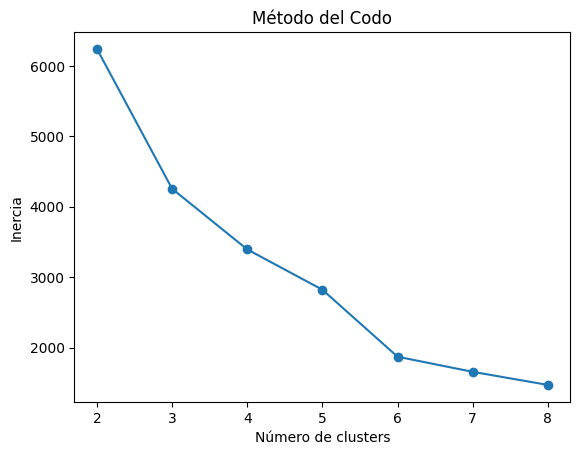

In [12]:
# Realizamos el método del codo
plt.plot(k_m, resultados, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

In [13]:
# Evaluamos el modelo final
kmeans_5 = KMeans(n_clusters=5)
kmeans_5.fit(X)
y_kmeans_5 = kmeans_5.predict(X)

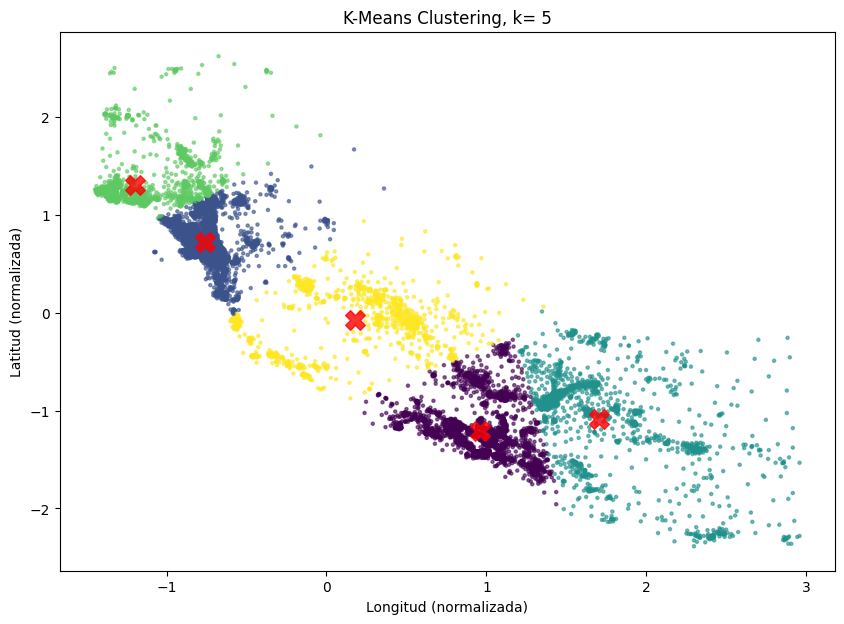

In [14]:
# Visualizamos los grupos
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans_5, s=5, cmap='viridis', alpha=0.6)

centers = kmeans_5.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8, marker='X', label='Centroides')

plt.title('K-Means Clustering, k= 5')
plt.xlabel('Longitud (normalizada)')
plt.ylabel('Latitud (normalizada)')
plt.show()

In [15]:
score = silhouette_score(X, y_kmeans_5)
print(f"Puntuación de silueta (k=5): {score:.3f}")

Puntuación de silueta (k=5): 0.562


En este caso, obtenemos peor puntación de silueta.

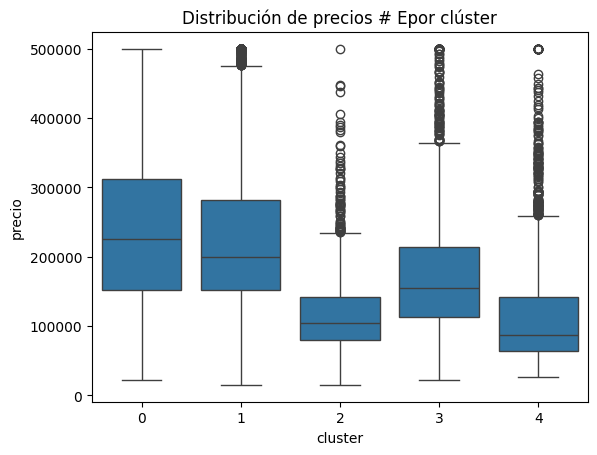

In [16]:
Y = df["median_house_value"]
df_result = pd.DataFrame({'cluster': y_kmeans_5, 'precio': Y})
sns.boxplot(x='cluster', y='precio', data=df_result)
plt.title('Distribución de precios # Epor clúster')
plt.show()

En este caso, geográficamente es mejor k=3 pero k=5 es más informativo en cuanto a los precios.
